# Steel Industry Energy Consumption Analysis

This project analyzes electricity consumption patterns in a steel industry dataset using SQL and DuckDB.

The objective is to build a small ETL pipeline that extracts raw data from a CSV file, validates and transforms the data, stores it in a structured DuckDB database, and uses SQL to identify patterns in energy consumption.

### Main Objectives

- Analyze energy consumption by operating load
- Identify hourly, daily, and monthly consumption patterns
- Compare weekday and weekend energy usage
- Examine energy consumption and recorded CO₂ emissions
- Analyze power factor behavior
- Identify monthly peak consumption hours

### Tools

- Python
- DuckDB
- SQL
- Pandas
- Matplotlib
- Jupyter Notebook

## 1. Project Overview

The dataset contains electricity consumption measurements from a steel industry facility during 2018. Measurements were recorded at 15-minute intervals.

The analysis uses DuckDB as the primary analytical database and SQL for data transformation and analysis.

### Workflow

**Raw CSV → Raw DuckDB Table → Data Validation → Transformation → Analytical Table → SQL Analysis → Visualization**

## 2. Environment Setup

In [115]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect('steel_energy.duckdb')

## 3. Data Extraction

The original CSV file is loaded into a raw DuckDB table. This table preserves the original structure and values of the source dataset before transformation.

In [116]:
con.sql("""
    CREATE OR REPLACE TABLE raw_steel_energy AS
    SELECT *
    FROM read_csv_auto('data/Steel_industry_data.csv')
""")

In [117]:
con.sql("""
    SELECT *
    FROM raw_steel_energy
    LIMIT 5
""")

┌──────────────────┬───────────┬──────────────────────────────────────┬──────────────────────────────────────┬───────────┬──────────────────────────────┬──────────────────────────────┬───────┬────────────┬─────────────┬────────────┐
│       date       │ Usage_kWh │ Lagging_Current_Reactive.Power_kVarh │ Leading_Current_Reactive_Power_kVarh │ CO2(tCO2) │ Lagging_Current_Power_Factor │ Leading_Current_Power_Factor │  NSM  │ WeekStatus │ Day_of_week │ Load_Type  │
│     varchar      │  double   │                double                │                double                │  double   │            double            │            double            │ int64 │  varchar   │   varchar   │  varchar   │
├──────────────────┼───────────┼──────────────────────────────────────┼──────────────────────────────────────┼───────────┼──────────────────────────────┼──────────────────────────────┼───────┼────────────┼─────────────┼────────────┤
│ 01/01/2018 00:15 │      3.17 │                                 2.9

In [118]:
con.sql("""
    SELECT COUNT(*) AS total_rows
    FROM raw_steel_energy
""")

┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│      35040 │
└────────────┘

In [119]:
con.sql("""
    DESCRIBE raw_steel_energy
""")

┌──────────────────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│             column_name              │ column_type │  null   │   key   │ default │  extra  │
│               varchar                │   varchar   │ varchar │ varchar │ varchar │ varchar │
├──────────────────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ date                                 │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Usage_kWh                            │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Lagging_Current_Reactive.Power_kVarh │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Leading_Current_Reactive_Power_kVarh │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ CO2(tCO2)                            │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Lagging_Current_Power_Factor         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ Leading_Current_Power_Factor         │ DOUBLE   

## 4. Data Quality Assessment

Before transforming the data, several quality checks were performed to identify missing values, duplicate timestamps, inconsistent categorical values, and unusual numerical values.

In [120]:
con.sql("""
    SELECT
        COUNT(*) - COUNT(date) AS missing_date,
        COUNT(*) - COUNT(Usage_kWh) AS missing_usage,
        COUNT(*) - COUNT("CO2(tCO2)") AS missing_co2,
        COUNT(*) - COUNT(WeekStatus) AS missing_week_status,
        COUNT(*) - COUNT(Day_of_week) AS missing_day,
        COUNT(*) - COUNT(Load_Type) AS missing_load_type
    FROM raw_steel_energy
""")

┌──────────────┬───────────────┬─────────────┬─────────────────────┬─────────────┬───────────────────┐
│ missing_date │ missing_usage │ missing_co2 │ missing_week_status │ missing_day │ missing_load_type │
│    int64     │     int64     │    int64    │        int64        │    int64    │       int64       │
├──────────────┼───────────────┼─────────────┼─────────────────────┼─────────────┼───────────────────┤
│            0 │             0 │           0 │                   0 │           0 │                 0 │
└──────────────┴───────────────┴─────────────┴─────────────────────┴─────────────┴───────────────────┘

No missing values were identified in the primary fields evaluated.

In [121]:
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT date) AS unique_timestamps
    FROM raw_steel_energy
""")

┌────────────┬───────────────────┐
│ total_rows │ unique_timestamps │
│   int64    │       int64       │
├────────────┼───────────────────┤
│      35040 │             35040 │
└────────────┴───────────────────┘

In [122]:
con.sql("""
    SELECT
        Load_Type AS category,
        COUNT(*) AS observations
    FROM raw_steel_energy
    GROUP BY Load_Type
    ORDER BY observations DESC
""")

┌──────────────┬──────────────┐
│   category   │ observations │
│   varchar    │    int64     │
├──────────────┼──────────────┤
│ Light_Load   │        18072 │
│ Medium_Load  │         9696 │
│ Maximum_Load │         7272 │
└──────────────┴──────────────┘

The dataset contains three operating load categories: Light Load, Medium Load, and Maximum Load. No inconsistent load categories were identified.

In [123]:
con.sql("""
    SELECT
        MIN(Usage_kWh) AS min_usage,
        MAX(Usage_kWh) AS max_usage,
        MIN("Lagging_Current_Reactive.Power_kVarh") AS min_lagging_reactive,
        MAX("Lagging_Current_Reactive.Power_kVarh") AS max_lagging_reactive,
        MIN(Leading_Current_Reactive_Power_kVarh) AS min_leading_reactive,
        MAX(Leading_Current_Reactive_Power_kVarh) AS max_leading_reactive,
        MIN(Lagging_Current_Power_Factor) AS min_lagging_pf,
        MAX(Lagging_Current_Power_Factor) AS max_lagging_pf,
        MIN(Leading_Current_Power_Factor) AS min_leading_pf,
        MAX(Leading_Current_Power_Factor) AS max_leading_pf
    FROM raw_steel_energy
""")

┌───────────┬───────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────┬────────────────┬────────────────┬────────────────┬────────────────┐
│ min_usage │ max_usage │ min_lagging_reactive │ max_lagging_reactive │ min_leading_reactive │ max_leading_reactive │ min_lagging_pf │ max_lagging_pf │ min_leading_pf │ max_leading_pf │
│  double   │  double   │        double        │        double        │        double        │        double        │     double     │     double     │     double     │     double     │
├───────────┼───────────┼──────────────────────┼──────────────────────┼──────────────────────┼──────────────────────┼────────────────┼────────────────┼────────────────┼────────────────┤
│       0.0 │    157.18 │                  0.0 │                96.91 │                  0.0 │                27.76 │            0.0 │          100.0 │            0.0 │          100.0 │
└───────────┴───────────┴──────────────────────┴──────────────────────

In [124]:
con.sql("""
    SELECT *
    FROM raw_steel_energy
    WHERE Usage_kWh = 0
""")

┌──────────────────┬───────────┬──────────────────────────────────────┬──────────────────────────────────────┬───────────┬──────────────────────────────┬──────────────────────────────┬───────┬────────────┬─────────────┬────────────┐
│       date       │ Usage_kWh │ Lagging_Current_Reactive.Power_kVarh │ Leading_Current_Reactive_Power_kVarh │ CO2(tCO2) │ Lagging_Current_Power_Factor │ Leading_Current_Power_Factor │  NSM  │ WeekStatus │ Day_of_week │ Load_Type  │
│     varchar      │  double   │                double                │                double                │  double   │            double            │            double            │ int64 │  varchar   │   varchar   │  varchar   │
├──────────────────┼───────────┼──────────────────────────────────────┼──────────────────────────────────────┼───────────┼──────────────────────────────┼──────────────────────────────┼───────┼────────────┼─────────────┼────────────┤
│ 07/11/2018 00:00 │       0.0 │                                  0.

One observation contains zero electricity consumption. The same observation also contains zero values for the electrical measurements and recorded CO₂.

Because the available data does not provide enough information to determine whether this represents a shutdown, measurement condition, or another operational event, the observation was retained.

## 5. Data Transformation

The raw dataset was transformed to create a cleaner structure for analysis.

The main transformations included:

- Converting the original date field from VARCHAR to TIMESTAMP
- Standardizing column names using snake_case
- Renaming technical variables for easier querying
- Creating an `hour` variable from the timestamp
- Preserving the original numerical measurements

## 6. ETL Pipeline

The transformed analytical table is created from the raw DuckDB table. This separates the original source data from the cleaned data used for analysis.

In [125]:
con.sql("""
    CREATE OR REPLACE TABLE steel_energy AS
    SELECT
        STRPTIME(date, '%d/%m/%Y %H:%M') AS timestamp,
        EXTRACT(HOUR FROM STRPTIME(date, '%d/%m/%Y %H:%M')) AS hour,
        Usage_kWh AS usage_kwh,
        "Lagging_Current_Reactive.Power_kVarh" AS lagging_reactive_power_kvarh,
        Leading_Current_Reactive_Power_kVarh AS leading_reactive_power_kvarh,
        "CO2(tCO2)" AS co2_tco2,
        Lagging_Current_Power_Factor AS lagging_power_factor,
        Leading_Current_Power_Factor AS leading_power_factor,
        NSM AS seconds_from_midnight,
        WeekStatus AS week_status,
        Day_of_week AS day_of_week,
        Load_Type AS load_type
    FROM raw_steel_energy
""")

con.sql("""
    SELECT *
    FROM steel_energy
    LIMIT 5
""")

In [127]:
con.sql("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT timestamp) AS unique_timestamps,
        MIN(timestamp) AS first_timestamp,
        MAX(timestamp) AS last_timestamp
    FROM steel_energy
""")

┌────────────┬───────────────────┬─────────────────────┬─────────────────────┐
│ total_rows │ unique_timestamps │   first_timestamp   │   last_timestamp    │
│   int64    │       int64       │      timestamp      │      timestamp      │
├────────────┼───────────────────┼─────────────────────┼─────────────────────┤
│      35040 │             35040 │ 2018-01-01 00:00:00 │ 2018-12-31 23:45:00 │
└────────────┴───────────────────┴─────────────────────┴─────────────────────┘

The transformation preserved all 35,040 observations and all timestamps remained unique. The resulting `steel_energy` table provides the cleaned analytical layer used for the remainder of the project.

## 7. Exploratory Analysis

The cleaned `steel_energy` table was analyzed using SQL to identify temporal and operational patterns in electricity consumption.

### 7.1 Consumption by Load Type

Average electricity consumption was compared across the three operating load categories.

In [128]:
load_summary = con.sql("""
    SELECT
        load_type,
        COUNT(*) AS observations,
        ROUND(AVG(usage_kwh), 2) AS avg_usage_kwh,
        ROUND(MIN(usage_kwh), 2) AS min_usage_kwh,
        ROUND(MAX(usage_kwh), 2) AS max_usage_kwh
    FROM steel_energy
    GROUP BY load_type
    ORDER BY avg_usage_kwh DESC
""").df()

load_summary

,load_type,observations,avg_usage_kwh,min_usage_kwh,max_usage_kwh
0,Maximum_Load,7272,59.27,2.92,151.67
1,Medium_Load,9696,38.45,2.52,157.18
2,Light_Load,18072,8.63,0.00,140.29


Maximum Load has the highest average electricity consumption at 59.27 kWh, followed by Medium Load at 38.45 kWh and Light Load at 8.63 kWh.

### 7.2 Hourly Consumption

Average electricity consumption was calculated for each hour of the day to identify periods of higher energy demand.

In [129]:
hourly = con.sql("""
    SELECT
        hour,
        ROUND(AVG(usage_kwh), 2) AS avg_usage_kwh
    FROM steel_energy
    GROUP BY hour
    ORDER BY hour
""").df()

hourly

,hour,avg_usage_kwh
0,0,7.87
1,1,6.07
2,2,4.43
3,3,4.36
4,4,4.31
5,5,4.25
6,6,4.22
7,7,4.50
8,8,37.70
9,9,58.55


In [130]:
con.sql("""
    SELECT
        hour,
        ROUND(AVG(usage_kwh), 2) AS avg_usage_kwh
    FROM steel_energy
    GROUP BY hour
    ORDER BY avg_usage_kwh DESC
    LIMIT 5
""")

┌───────┬───────────────┐
│ hour  │ avg_usage_kwh │
│ int64 │    double     │
├───────┼───────────────┤
│     9 │         58.55 │
│    11 │          57.1 │
│    14 │         56.16 │
│    10 │         55.87 │
│    16 │          55.8 │
└───────┴───────────────┘

Electricity consumption is relatively low during overnight hours and increases sharply during the morning. The highest overall hourly average occurs at 09:00, with 58.55 kWh.

### 7.3 Weekday vs Weekend Consumption

In [131]:
week_summary = con.sql("""
    SELECT
        week_status,
        COUNT(*) AS observations,
        ROUND(AVG(usage_kwh), 2) AS avg_usage_kwh,
        ROUND(MAX(usage_kwh), 2) AS max_usage_kwh
    FROM steel_energy
    GROUP BY week_status
    ORDER BY avg_usage_kwh DESC
""").df()

week_summary

,week_status,observations,avg_usage_kwh,max_usage_kwh
0,Weekday,25056,33.62,157.18
1,Weekend,9984,11.73,133.42


Average weekday consumption is 33.62 kWh, compared with 11.73 kWh during weekends, indicating substantially higher energy demand during weekdays.

In [132]:
daily = con.sql("""
    SELECT
        day_of_week,
        ROUND(AVG(usage_kwh), 2) AS avg_usage_kwh
    FROM steel_energy
    GROUP BY day_of_week
    ORDER BY avg_usage_kwh DESC
""").df()

daily

,day_of_week,avg_usage_kwh
0,Thursday,35.11
1,Tuesday,34.43
2,Friday,33.20
3,Monday,33.14
4,Wednesday,32.25
5,Saturday,15.92
6,Sunday,7.55


Thursday has the highest average consumption at 35.11 kWh, while Sunday has the lowest at 7.55 kWh. The results also show a clear reduction in average energy consumption during the weekend.

In [133]:
monthly = con.sql("""
    SELECT
        EXTRACT(MONTH FROM timestamp) AS month,
        ROUND(AVG(usage_kwh), 2) AS avg_usage_kwh
    FROM steel_energy
    GROUP BY month
    ORDER BY month
""").df()

monthly

,month,avg_usage_kwh
0,1,42.42
1,2,34.04
2,3,26.96
3,4,27.35
4,5,26.57
5,6,22.71
6,7,27.44
7,8,23.04
8,9,20.10
9,10,28.45


Energy consumption varies throughout the year. January has the highest monthly average at 42.42 kWh, while December has the lowest at 19.97 kWh.

In [134]:
load_co2 = con.sql("""
    SELECT
        load_type,
        ROUND(AVG(usage_kwh), 2) AS avg_usage_kwh,
        ROUND(AVG(co2_tco2), 4) AS avg_co2_tco2
    FROM steel_energy
    GROUP BY load_type
    ORDER BY avg_usage_kwh DESC
""").df()

load_co2

,load_type,avg_usage_kwh,avg_co2_tco2
0,Maximum_Load,59.27,0.0269
1,Medium_Load,38.45,0.0167
2,Light_Load,8.63,0.0026


Higher operating load categories are associated with both higher average electricity consumption and higher recorded CO₂ values. Maximum Load has the highest averages for both measures, while Light Load has the lowest.

This analysis identifies an association between the variables and does not establish a causal relationship.

In [135]:
power_factor = con.sql("""
    SELECT
        load_type,
        ROUND(AVG(lagging_power_factor), 2) AS avg_lagging_pf,
        ROUND(AVG(leading_power_factor), 2) AS avg_leading_pf
    FROM steel_energy
    GROUP BY load_type
    ORDER BY avg_lagging_pf DESC
""").df()

power_factor

,load_type,avg_lagging_pf,avg_leading_pf
0,Medium_Load,93.06,73.91
1,Maximum_Load,91.01,95.73
2,Light_Load,69.68,85.41


Power factor varies across operating load categories. Medium and Maximum Load conditions show higher average lagging power factor values than Light Load conditions.

## 8. Advanced SQL Analysis

A CTE and window function were used to identify the hour with the highest average electricity consumption for each month.

In [136]:
monthly_peaks = con.sql("""
    WITH hourly_monthly_usage AS (
        SELECT
            EXTRACT(MONTH FROM timestamp) AS month,
            hour,
            AVG(usage_kwh) AS avg_usage_kwh
        FROM steel_energy
        GROUP BY month, hour
    ),
    ranked_hours AS (
        SELECT
            month,
            hour,
            avg_usage_kwh,
            ROW_NUMBER() OVER (
                PARTITION BY month
                ORDER BY avg_usage_kwh DESC
            ) AS usage_rank
        FROM hourly_monthly_usage
    )
    SELECT
        month,
        hour AS peak_hour,
        ROUND(avg_usage_kwh, 2) AS avg_usage_kwh
    FROM ranked_hours
    WHERE usage_rank = 1
    ORDER BY month
""").df()

monthly_peaks

,month,peak_hour,avg_usage_kwh
0,1,11,77.17
1,2,9,57.66
2,3,9,64.80
3,4,9,63.08
4,5,15,58.04
5,6,14,51.27
6,7,9,61.79
7,8,9,52.59
8,9,14,47.36
9,10,9,64.04


The peak consumption hour varies throughout the year. However, 09:00 is the most frequent monthly peak hour, occurring in seven of the twelve months.

## 9. Data Visualization

The main consumption patterns identified through SQL are summarized in the following visualizations.

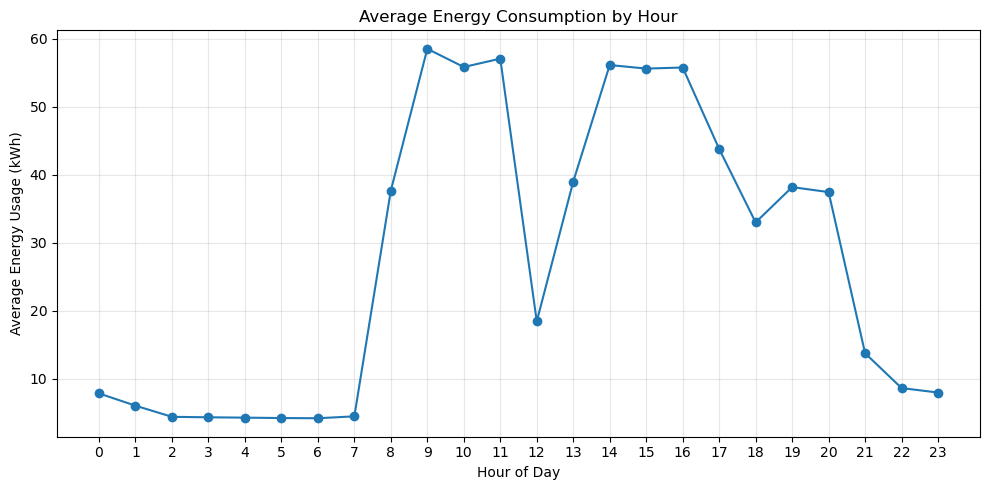

In [137]:
plt.figure(figsize=(10, 5))
plt.plot(hourly['hour'], hourly['avg_usage_kwh'], marker='o')

plt.title('Average Energy Consumption by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Usage (kWh)')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('images/hourly_energy.png', dpi=300, bbox_inches='tight')
plt.show()

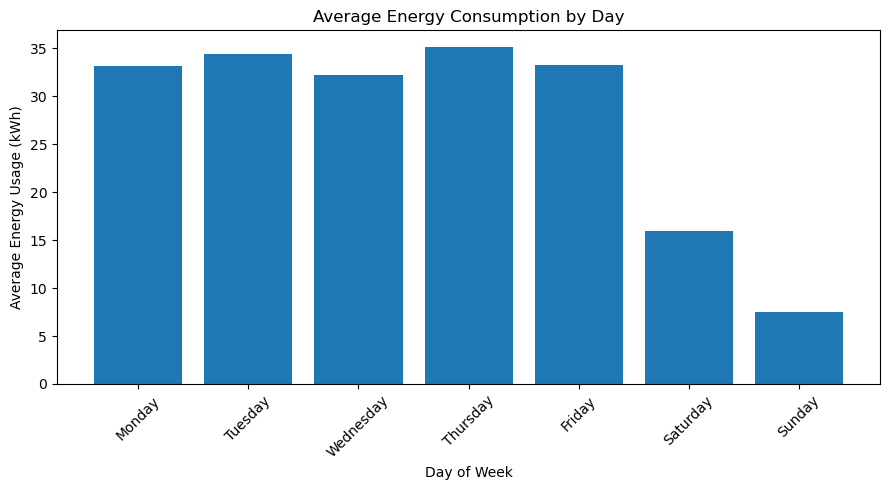

In [138]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_plot = daily.copy()

daily_plot['day_of_week'] = pd.Categorical(
    daily_plot['day_of_week'],
    categories=day_order,
    ordered=True
)

daily_plot = daily_plot.sort_values('day_of_week')

plt.figure(figsize=(9, 5))
plt.bar(daily_plot['day_of_week'], daily_plot['avg_usage_kwh'])

plt.title('Average Energy Consumption by Day')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy Usage (kWh)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('images/daily_energy.png', dpi=300, bbox_inches='tight')
plt.show()

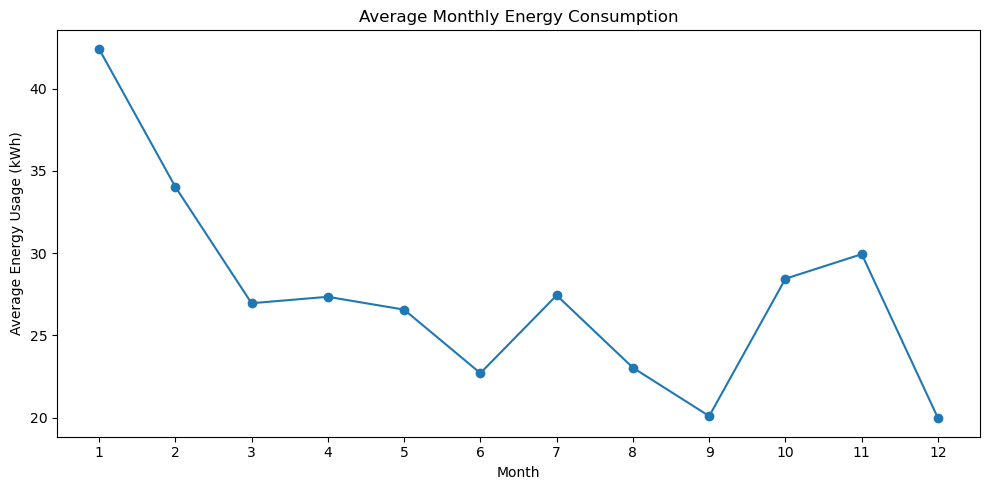

In [139]:
plt.figure(figsize=(10, 5))
plt.plot(monthly['month'], monthly['avg_usage_kwh'], marker='o')

plt.title('Average Monthly Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Average Energy Usage (kWh)')
plt.xticks(range(1, 13))
plt.tight_layout()

plt.savefig('images/monthly_energy.png', dpi=300, bbox_inches='tight')
plt.show()

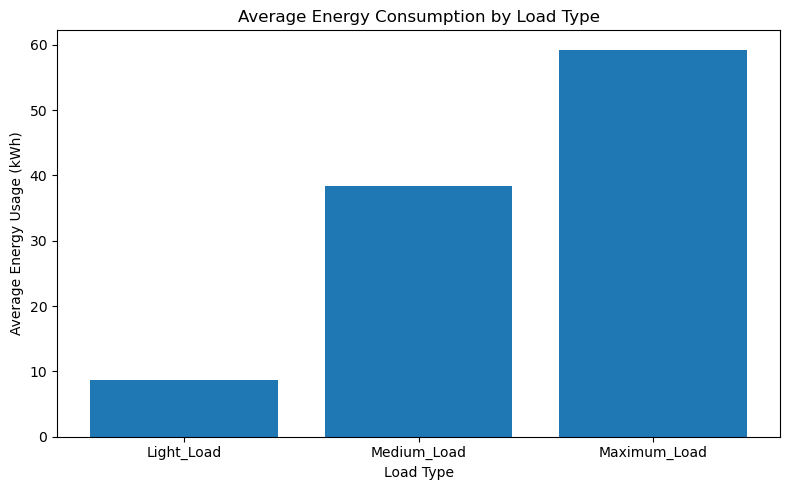

In [140]:
load_plot = load_summary.sort_values('avg_usage_kwh')

plt.figure(figsize=(8, 5))
plt.bar(load_plot['load_type'], load_plot['avg_usage_kwh'])

plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Energy Usage (kWh)')
plt.tight_layout()

plt.savefig('images/load_type_energy.png', dpi=300, bbox_inches='tight')
plt.show()

## Key Findings

- Energy consumption follows a clear daily operating pattern. Average usage is low overnight and increases sharply during working hours.
- The highest overall hourly average occurs at 09:00, with approximately 58.55 kWh.
- The defined working-hours period averages 48.26 kWh, compared with 26.14 kWh during the evening and 5.00 kWh at night.
- Weekday average consumption is 33.62 kWh, substantially higher than the weekend average of 11.73 kWh.
- Thursday shows the highest average consumption among weekdays at 35.11 kWh, while Sunday has the lowest overall average at 7.55 kWh.
- January records the highest monthly average energy consumption at 42.42 kWh.
- Average consumption increases substantially across load categories, from 8.63 kWh during Light Load to 38.45 kWh during Medium Load and 59.27 kWh during Maximum Load.
- Recorded CO₂ values also increase across these load categories, suggesting a strong association between higher energy demand and higher recorded emissions.
- Peak consumption time varies throughout the year. However, 09:00 is the most frequent monthly peak hour, appearing as the peak in seven of the twelve months.

## Conclusion

The analysis identified clear temporal and operational patterns in the steel facility's electricity consumption. Energy demand is concentrated primarily during weekday working hours, while nights and weekends show substantially lower average consumption.

The analysis also found that higher operating load categories are associated with higher electricity consumption and recorded CO₂ emissions. Monthly peak-demand analysis showed that peak timing varies throughout the year, although 09:00 was the most frequent peak hour.

These findings could support further investigation into production scheduling, peak-demand management, energy efficiency, and emissions monitoring.